In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
hour_df = pd.read_csv('../data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [76]:
hour_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [77]:
hour_df['hr'].value_counts()

hr
16    730
17    730
13    729
14    729
15    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
7     727
8     727
9     727
10    727
11    727
0     726
6     725
1     724
5     717
2     715
3     697
4     697
Name: count, dtype: int64

array([[<Axes: title={'center': 'instant'}>,
        <Axes: title={'center': 'season'}>,
        <Axes: title={'center': 'yr'}>, <Axes: title={'center': 'mnth'}>],
       [<Axes: title={'center': 'hr'}>,
        <Axes: title={'center': 'holiday'}>,
        <Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'workingday'}>],
       [<Axes: title={'center': 'weathersit'}>,
        <Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>,
        <Axes: title={'center': 'hum'}>],
       [<Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'casual'}>,
        <Axes: title={'center': 'registered'}>,
        <Axes: title={'center': 'cnt'}>]], dtype=object)

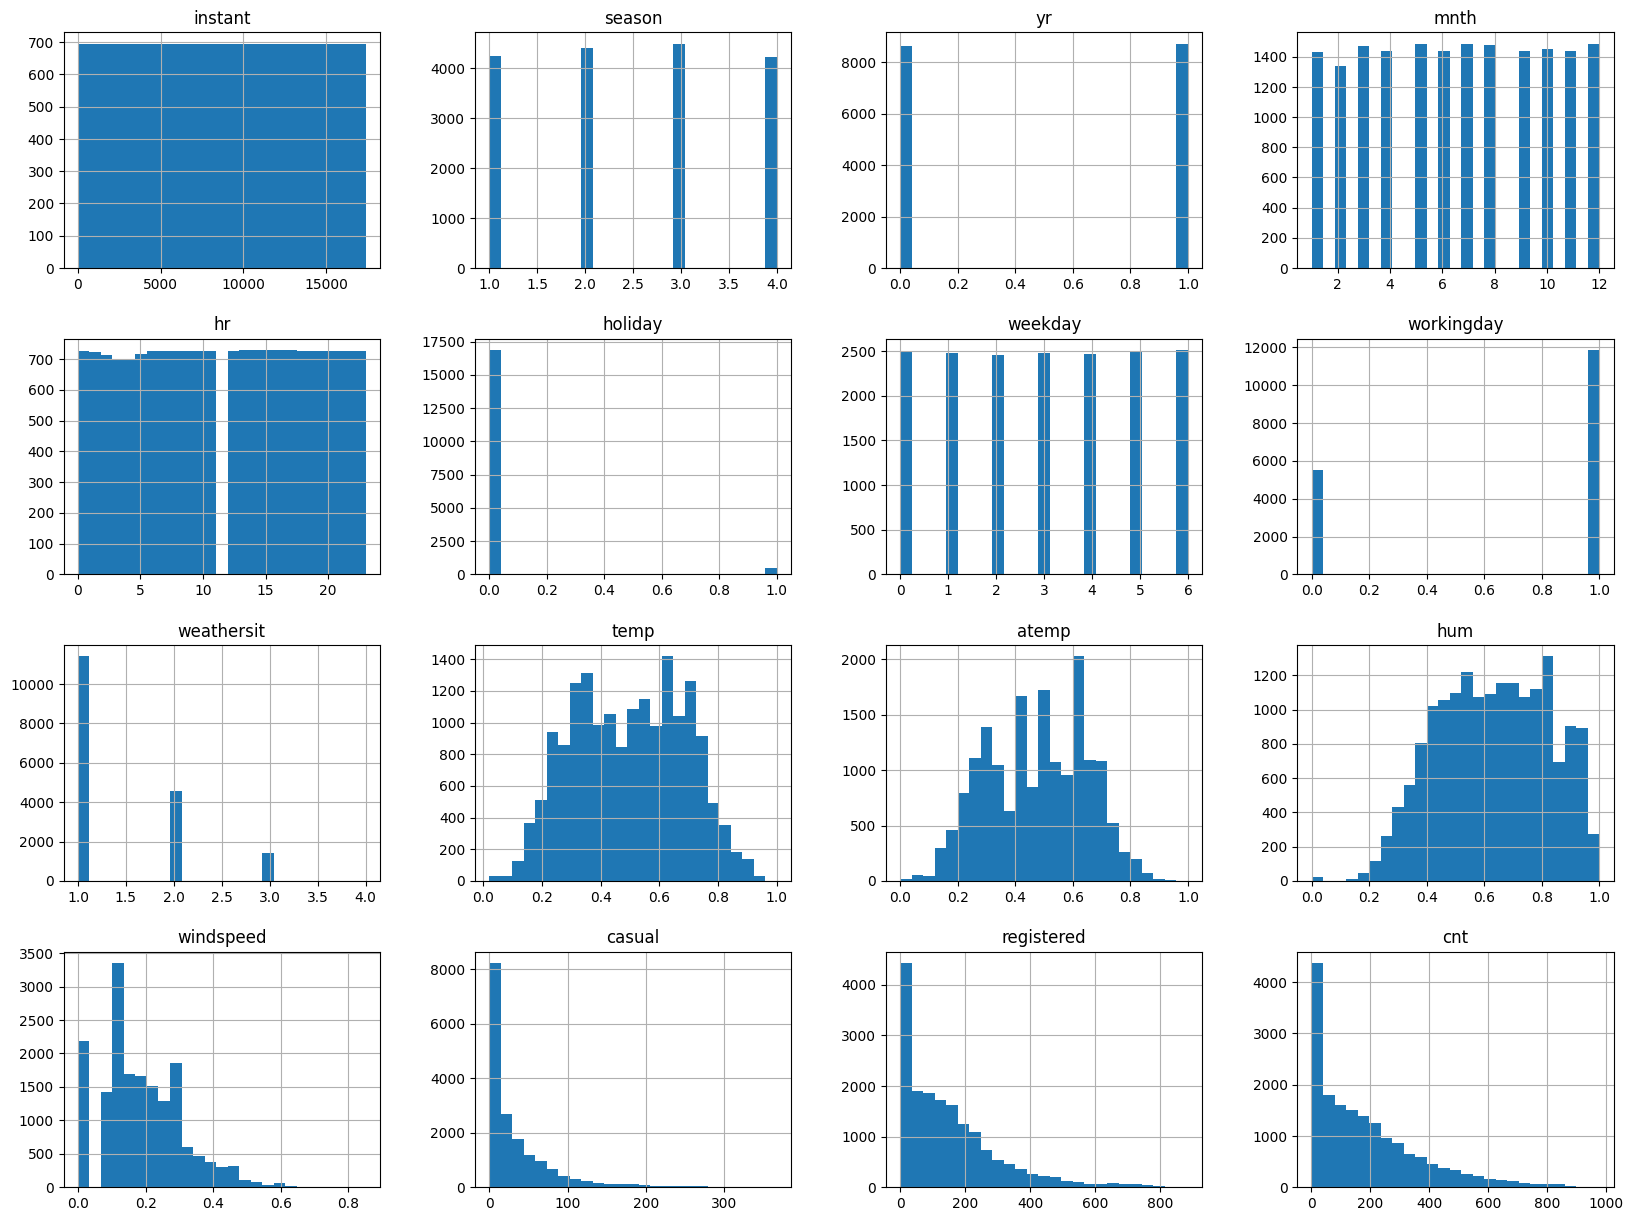

In [78]:
hour_df.hist(bins=25, figsize=(20,15))

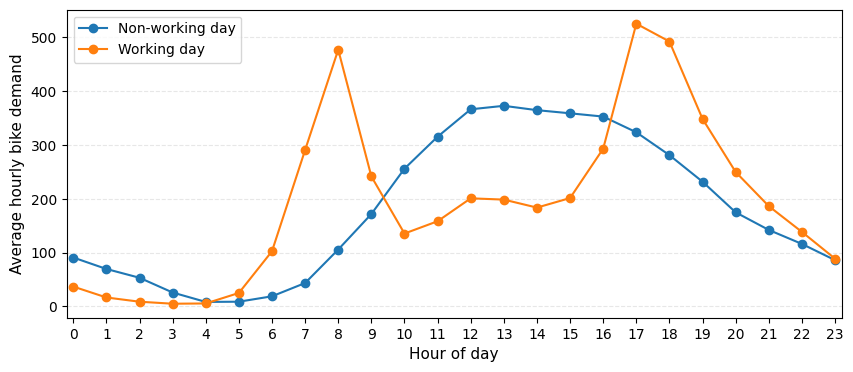

In [79]:
hourly = (
    hour_df
    .groupby(["hr", "workingday"])["cnt"]
    .mean()
    .unstack()
)

ax = hourly.plot(
    marker = 'o',
    figsize=(10, 4),
)
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.2, 23.2)

ax.set_xlabel("Hour of day",fontsize=11)
ax.set_ylabel("Average hourly bike demand",fontsize=11)
ax.legend(["Non-working day", "Working day"])
plt.xticks(rotation=0)
plt.show()

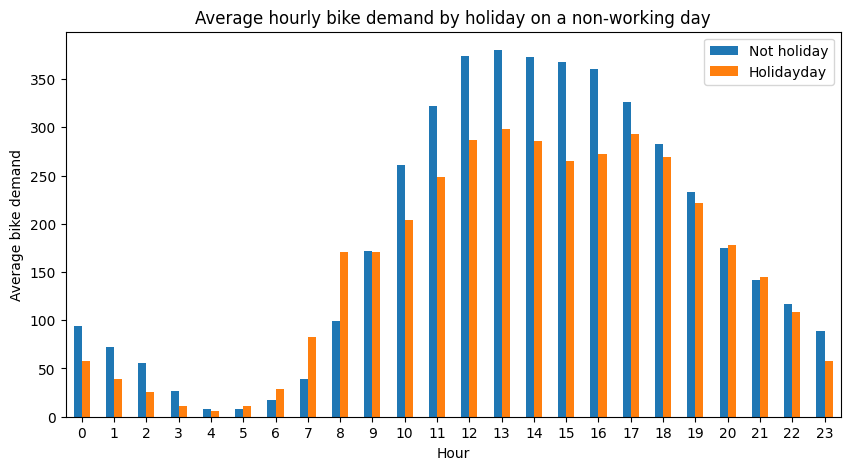

In [80]:
hourly = (
    hour_df[hour_df["workingday"]==0]
    .groupby(["hr", "holiday"])["cnt"]
    .mean()
    .unstack()
)

ax = hourly.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_xlabel("Hour")
ax.set_ylabel("Average bike demand")
ax.set_title("Average hourly bike demand by holiday on a non-working day")
ax.legend(["Not holiday", "Holidayday"])
plt.xticks(rotation=0)
plt.show()

In [81]:
hour_df['holiday'].value_counts()

holiday
0    16879
1      500
Name: count, dtype: int64

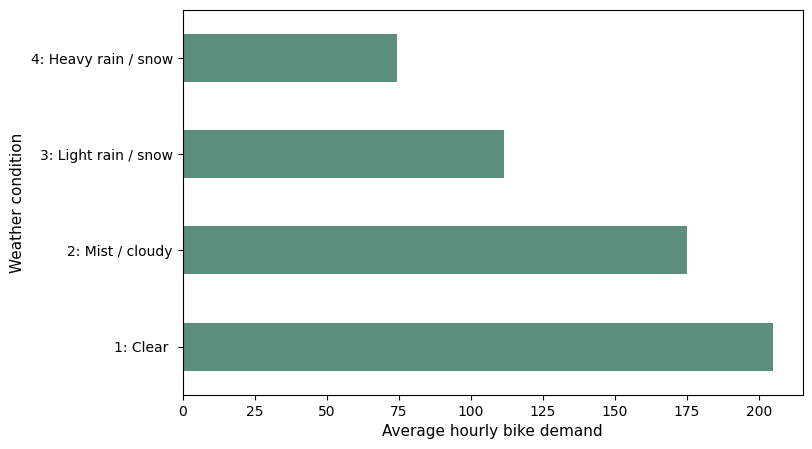

In [82]:
ax = hour_df.groupby('weathersit')['cnt'].mean().plot(kind='barh', figsize=(8,5), color="#5B8E7D")
ax.set_ylabel("Weather condition",fontsize=11)
ax.set_yticklabels(["1: Clear ","2: Mist / cloudy", "3: Light rain / snow", "4: Heavy rain / snow"])
ax.set_xlabel("Average hourly bike demand",fontsize=11)
plt.xticks(rotation=0)
plt.show()

In [83]:
hour_df.groupby("weathersit")["cnt"].agg(
    ["count", "mean", "median", "std"]
)


,count,mean,median,std
weathersit,,,,
1,11413,204.869272,159.0,189.487773
2,4544,175.165493,133.0,165.431589
3,1419,111.579281,63.0,133.781045
4,3,74.333333,36.0,77.925178


<Axes: xlabel='temp'>

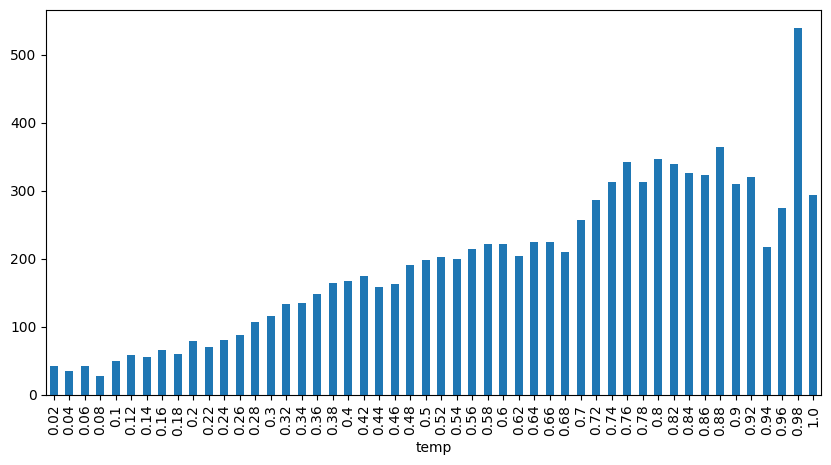

In [84]:
hour_df.groupby('temp')['cnt'].mean().plot(kind='bar', figsize=(10,5))

<Axes: xlabel='atemp'>

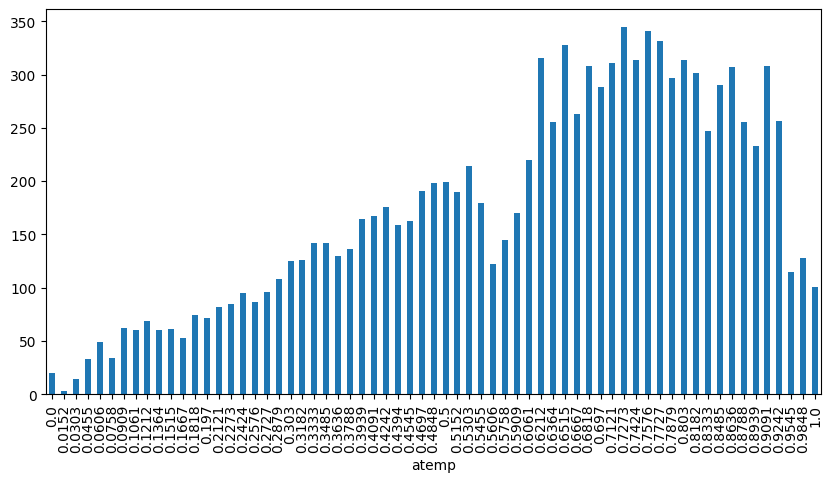

In [85]:
hour_df.groupby('atemp')['cnt'].mean().plot(kind='bar', figsize=(10,5))

<Axes: xlabel='hum'>

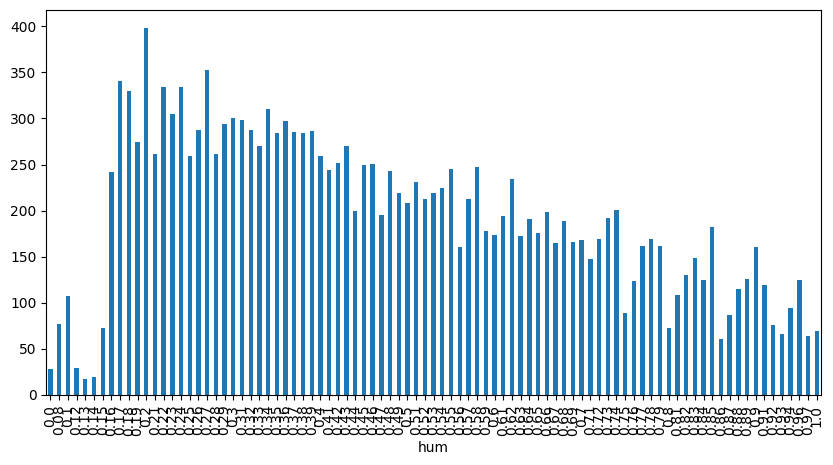

In [86]:
hour_df.groupby('hum')['cnt'].mean().plot(kind='bar', figsize=(10,5))

<Axes: xlabel='windspeed'>

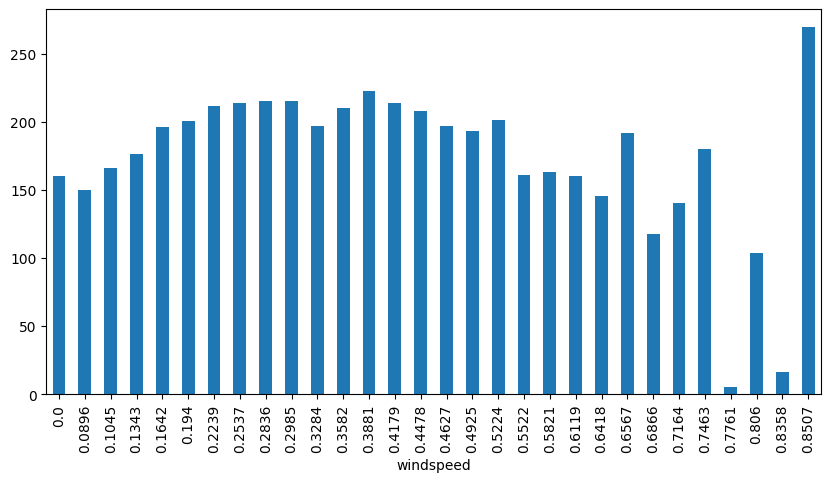

In [87]:
hour_df.groupby('windspeed')['cnt'].mean().plot(kind='bar', figsize=(10,5))

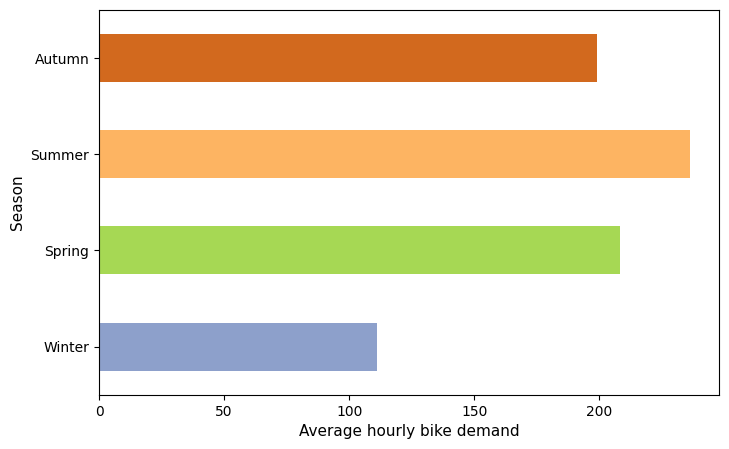

In [88]:
colors = [
    "#8DA0CB",  # Winter - soft blue
    "#A6D854",  # Spring - green
    "#FDB462",  # Summer - orange 
    "#D2691E",  # Autumn - brown
]
ax = hour_df.groupby('season')['cnt'].mean().plot(kind='barh', figsize=(8,5), color=colors)
ax.set_ylabel("Season",fontsize=11)
ax.set_yticklabels(["Winter","Spring","Summer","Autumn"])
ax.set_xlabel("Average hourly bike demand",fontsize=11)
plt.xticks(rotation=0)
plt.show()

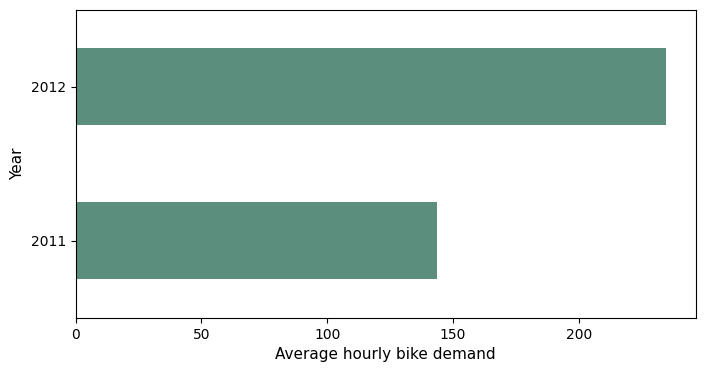

In [89]:
ax = hour_df.groupby('yr')['cnt'].mean().plot(kind='barh', figsize=(8,4),color="#5B8E7D")
ax.set_ylabel("Year",fontsize=11)
ax.set_yticklabels(["2011","2012"])
ax.set_xlabel("Average hourly bike demand",fontsize=11 )
plt.xticks(rotation=0)
plt.show()

<Axes: ylabel='workingday'>

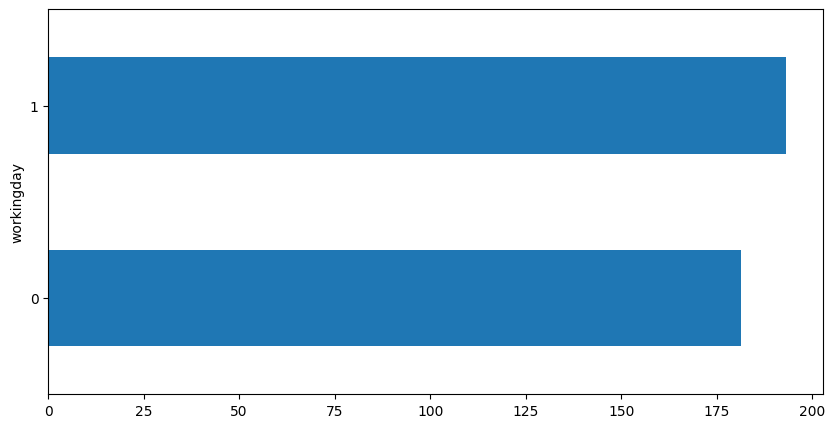

In [90]:
hour_df.groupby('workingday')['cnt'].mean().plot(kind='barh' , figsize=(10,5))

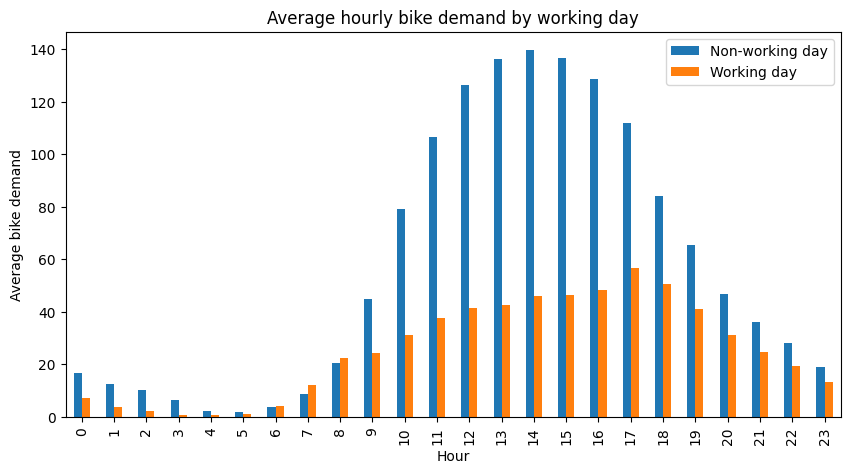

In [91]:
hourly = (
    hour_df
    .groupby(["hr", "workingday"])["casual"]
    .mean()
    .unstack()
)

ax = hourly.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_xlabel("Hour")
ax.set_ylabel("Average bike demand")
ax.set_title("Average hourly bike demand by working day")
ax.legend(["Non-working day", "Working day"])

plt.show()

In [92]:
hour_df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

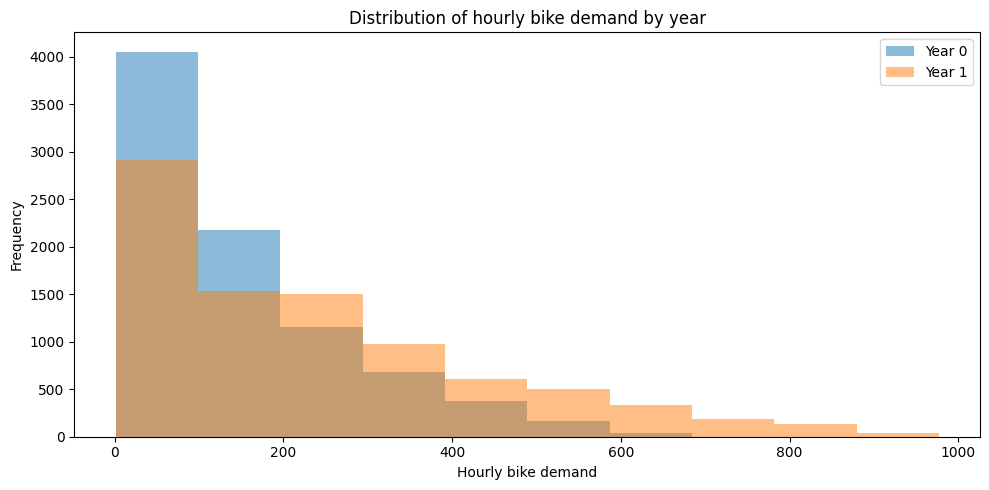

In [93]:
min_cnt = hour_df["cnt"].min()
max_cnt = hour_df["cnt"].max()
bin_edges = np.linspace(min_cnt, max_cnt, 11)  # 10 bins
fig, ax = plt.subplots(figsize=(10, 5))
for year, group in hour_df.groupby("yr"):
    ax.hist(
        group["cnt"],
        bins=bin_edges,
        alpha=0.5,
        label=f"Year {year}",
    )
ax.set_xlabel("Hourly bike demand")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of hourly bike demand by year")
ax.legend()

plt.tight_layout()
plt.show()

<Axes: >

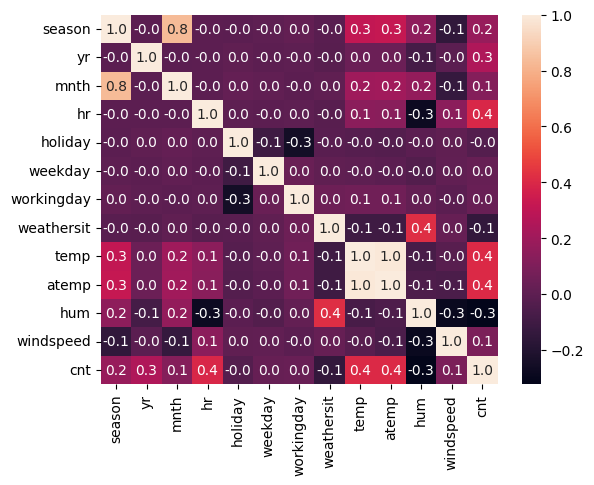

In [94]:
import seaborn as sns
sns.heatmap(hour_df.drop(columns=['instant', 'dteday', 'casual', 'registered']).corr(), annot=True, fmt= '.1f')
